# TCGA-PAAD Hot/Cold immune-TME panel

Scores are continuous panel means of per-gene Z-scores across samples. This notebook intentionally does not classify samples with arbitrary Hot/Cold thresholds.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
HOT = ['CD8A', 'CD8B', 'IFNG', 'GZMB', 'PRF1', 'NKG7', 'CXCL9', 'CXCL10', 'CXCL11', 'STAT1', 'IRF1', 'HLA-A', 'HLA-B', 'HLA-C', 'B2M']
COLD = ['TGFB1', 'CXCL12', 'POSTN', 'HIF1A', 'VEGFA', 'KDR', 'FAP', 'COL1A1', 'CD163', 'CSF1R', 'FOXP3', 'IL10']
expression = pd.read_csv(PROCESSED / 'PAAD_27gene_log2_counts.csv', index_col='gene_symbol')
metadata = pd.read_csv(PROCESSED / 'PAAD_sample_metadata.csv').set_index('sample_id')
print(f'Expression matrix: {expression.shape[0]} genes x {expression.shape[1]} samples')
print('Missing values:', int(expression.isna().sum().sum()))

Expression matrix: 27 genes x 178 samples
Missing values: 0


In [2]:
available_hot = [gene for gene in HOT if gene in expression.index]
available_cold = [gene for gene in COLD if gene in expression.index]
missing_hot = sorted(set(HOT) - set(available_hot))
missing_cold = sorted(set(COLD) - set(available_cold))
print('Available Hot genes:', len(available_hot), '| Missing:', missing_hot if missing_hot else 'None')
print('Available Cold genes:', len(available_cold), '| Missing:', missing_cold if missing_cold else 'None')
# ddof=0 gives a population Z-score over the analyzed TCGA-PAAD samples.
row_std = expression.std(axis=1, ddof=0).replace(0, float('nan'))
z_scores = expression.sub(expression.mean(axis=1), axis=0).div(row_std, axis=0)
scores = pd.DataFrame({
    'sample_id': expression.columns,
    'Hot_score': z_scores.loc[available_hot].mean(axis=0).values,
    'Cold_score': z_scores.loc[available_cold].mean(axis=0).values,
    'hot_genes_used': len(available_hot),
    'cold_genes_used': len(available_cold),
}).set_index('sample_id').join(metadata[['case_id', 'sample_type', 'project', 'file_uuid']])
scores.to_csv(PROCESSED / 'PAAD_Hot_Cold_scores.csv')
display(scores.head())

Available Hot genes: 15 | Missing: None
Available Cold genes: 12 | Missing: None


,Hot_score,Cold_score,hot_genes_used,cold_genes_used,case_id,sample_type,project,file_uuid
sample_id,,,,,,,,
TCGA-IB-7888-01A,0.125966,0.298473,15,12,05d2adb3-5c6d-4edc-ba4c-bdbf628f4eee,Primary Tumor,TCGA-PAAD,a4d0115d-3bb1-41df-b2a8-823cebc7104a
TCGA-FB-A78T-01A,0.214544,0.032587,15,12,2ad10199-1381-42b7-b54f-da34c1b1d3c0,Primary Tumor,TCGA-PAAD,f253cd32-9c55-4541-8c6c-5e4a1db99ee1
TCGA-2J-AABI-01A,0.061490,0.088744,15,12,2aaf212f-000a-4a9d-8a4a-198fa94f491e,Primary Tumor,TCGA-PAAD,fbd81952-f83a-4a24-86f8-5a415a722499
TCGA-HZ-7918-01A,1.619292,0.714272,15,12,620e0648-ec20-4a12-a6cb-5546fe829c77,Primary Tumor,TCGA-PAAD,649f4d81-a634-4734-ba31-bdeb0877312a
TCGA-2J-AABO-01A,-0.996076,-0.492956,15,12,a8c3e333-865d-4060-8ce4-453aa6f9f0e8,Primary Tumor,TCGA-PAAD,4a1c8620-73ce-4be9-ae64-589afb3007d9


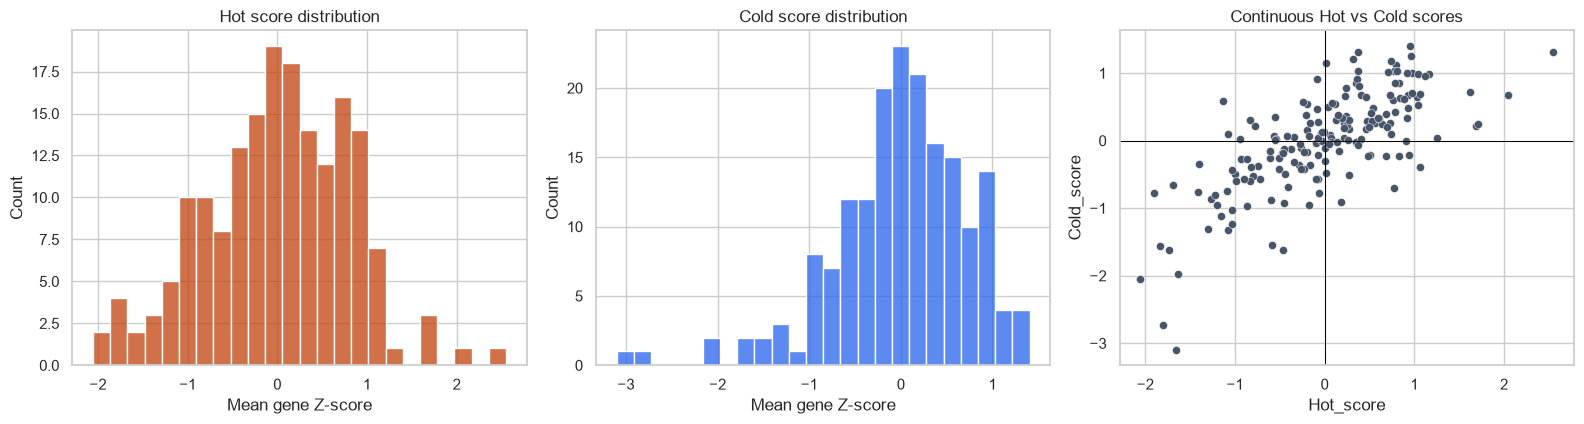

In [3]:
sns.set_theme(style='whitegrid', context='notebook')
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
sns.histplot(scores['Hot_score'], bins=24, ax=axes[0], color='#c2410c')
axes[0].set(title='Hot score distribution', xlabel='Mean gene Z-score')
sns.histplot(scores['Cold_score'], bins=24, ax=axes[1], color='#2563eb')
axes[1].set(title='Cold score distribution', xlabel='Mean gene Z-score')
sns.scatterplot(data=scores, x='Hot_score', y='Cold_score', ax=axes[2], color='#475569', s=34, edgecolor='white', linewidth=0.35)
axes[2].axhline(0, color='black', linewidth=0.7)
axes[2].axvline(0, color='black', linewidth=0.7)
axes[2].set(title='Continuous Hot vs Cold scores')
fig.tight_layout()
fig.savefig(FIGURES / 'PAAD_Hot_Cold_score_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

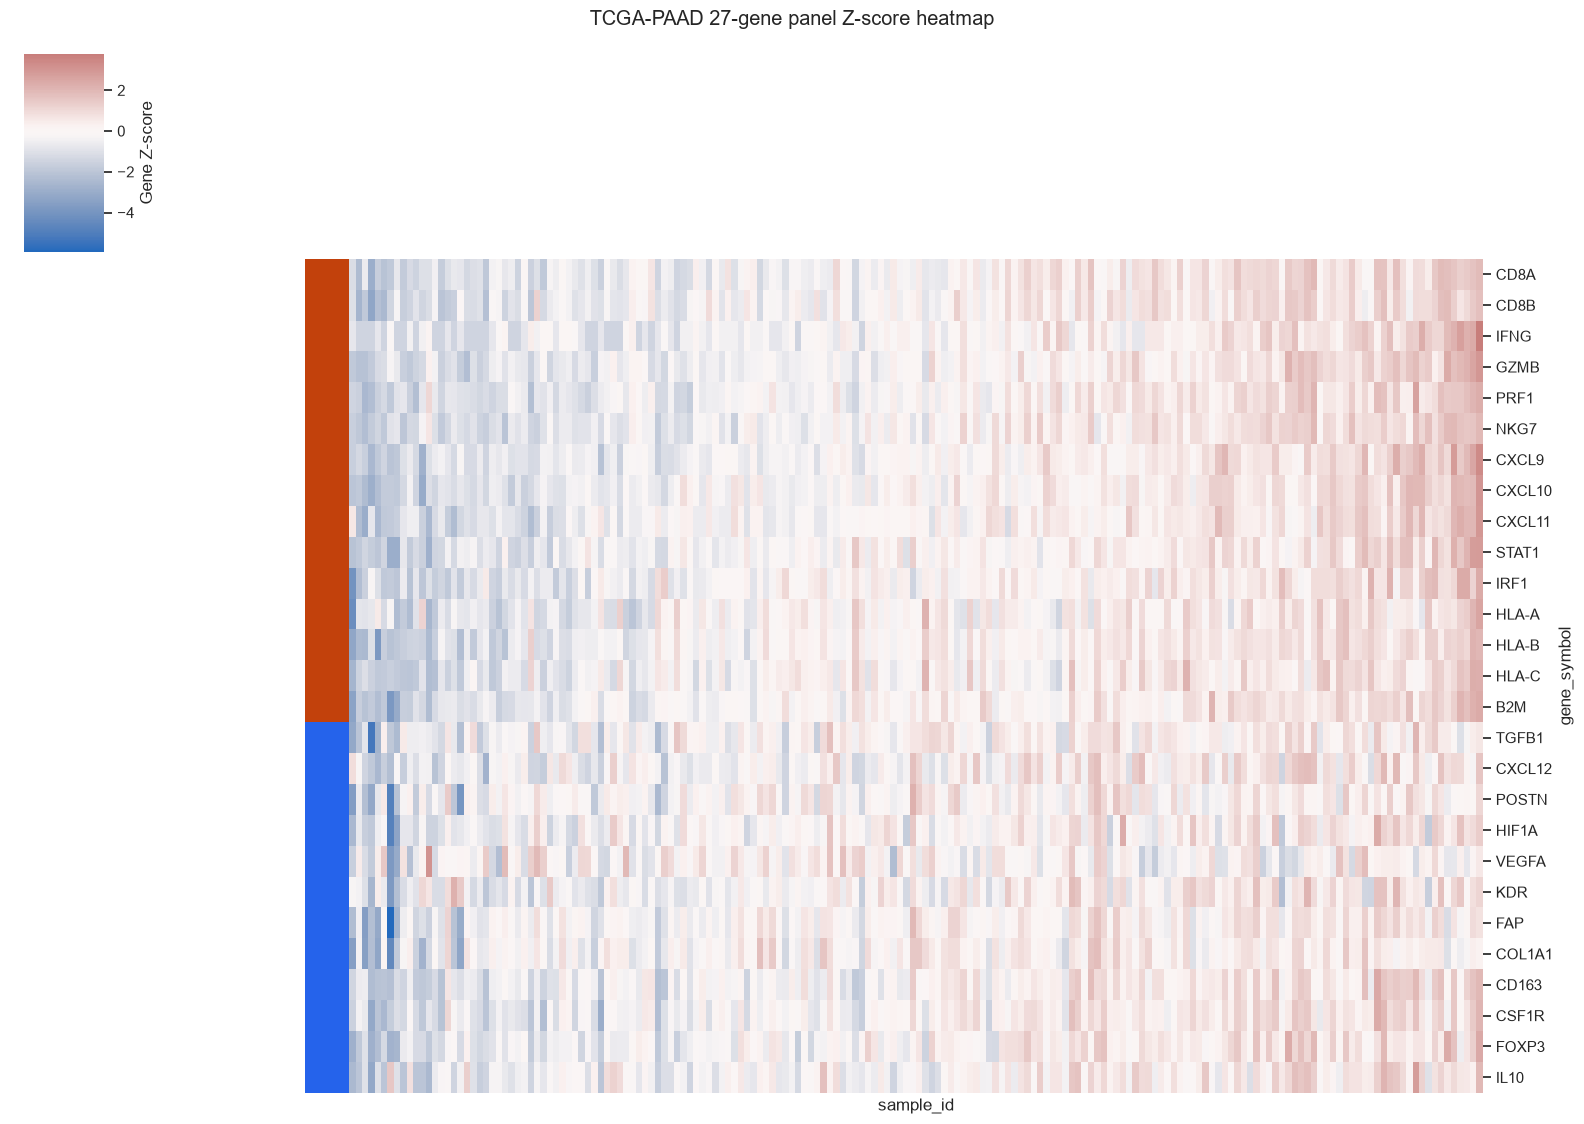

Saved: F:\Code\AI\Cancer_Immune_Analysis\data\processed\PAAD_Hot_Cold_scores.csv


In [4]:
ordered_samples = scores.sort_values(['Hot_score', 'Cold_score']).index
row_colors = ['#c2410c'] * len(available_hot) + ['#2563eb'] * len(available_cold)
grid = sns.clustermap(z_scores.loc[available_hot + available_cold, ordered_samples], row_cluster=False, col_cluster=False, row_colors=row_colors, cmap='vlag', center=0, xticklabels=False, yticklabels=True, figsize=(16, 11), cbar_kws={'label': 'Gene Z-score'})
grid.fig.suptitle('TCGA-PAAD 27-gene panel Z-score heatmap', y=1.02)
grid.savefig(FIGURES / 'PAAD_27gene_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', PROCESSED / 'PAAD_Hot_Cold_scores.csv')